In [13]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf

###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study3.0Pilot2'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.respon

Data Processing (fix string representations of lists)

In [14]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



Sanity Checks

In [15]:
#Look at fertility score in training by participant/category in accomodate task
df = df_accommodate[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high             7.4
1      low          3.5125


In [16]:
#Look at fertility score in training by participant/category in predict task
df = df_predict[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high             7.4
1      low          3.5125


In [17]:
#Overall means by category in accommodate task (participant responses)
df = df_accommodate[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high             7.325
1      low               4.3


In [18]:
#Overall means by actual testing category in prediction task
df = df_predict[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high               6.9
1      low              4.15


In [19]:
df_combined.groupby('irrelevant_dim')['feet_high'].value_counts() #Should be perfectly equal (or roughly equal after dropping participants)


irrelevant_dim  feet_high
color           C            10
                F            10
feet            C            10
                F            10
Name: count, dtype: int64

In [ ]:
#Checking to see how often a feature dimension was said to be relevant, relative to when it was actually relevant
#Point of test: get a subjective sense for whether participants are more likely to say a given feature is relevant
#Irrespective of whether it actually is relevant
mask = (
    (df_combined['relevant_dim'] == 'feet')
)


#print(df_combined.loc[mask, cols_to_show])
cols_to_show = [
    'feet_direction_slider.response',
    'feet_high',
    'feet_continuous_slider.response'
]

mask = (
    (df_combined['irrelevant_dim'] == 'feet')
)

#print(df_combined.loc[mask, cols_to_show])
print(df_combined[cols_to_show])

   feet_direction_slider.response feet_high  feet_continuous_slider.response
0                           Round         C                              4.0
1                             NaN         F                              NaN
2                    Curly/Pointy         F                              7.0
3                           Round         F                              5.0
4                    Curly/Pointy         C                              4.0
5                    Curly/Pointy         C                              5.0
6                    Curly/Pointy         C                              6.0
7                             NaN         F                              NaN
8                           Round         F                              6.0
9                           Round         F                              6.0
10                   Curly/Pointy         C                              6.0
11                            NaN         C                              NaN

Timing

task
accommodate    650.474105
predict        356.455270
Name: trial_stop_time, dtype: float64


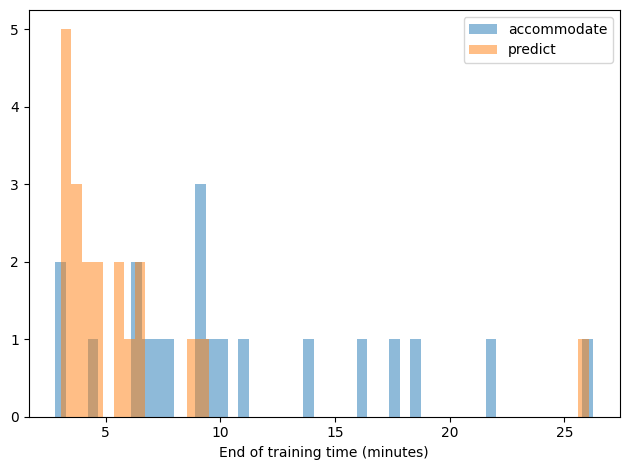

In [21]:
#Look at average time across task
df_combined['trial_stop_time'].describe()
avg_time = df_combined.groupby(['task'])['trial_stop_time'].mean()
print(avg_time)

for task, subdf in df_combined.groupby('task'):
    plt.hist(
        subdf['trial_stop_time']/60,
        bins=50,
        alpha=0.5,
        label=task
    )

plt.xlabel('End of training time (minutes)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure1TrialStopTimeByTask.png'))
plt.show()


**Primary Analysis #1**

Part 1: Model Parameter Score Complexity across conditions

In [22]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_combined.iterrows():
    feet_yes  = 1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0

    model_param_score = feet_yes + color_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'irrelevant_dim': row['irrelevant_dim'],
        'feet_high': row['feet_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate     10     10
predict         10     10
Chi-square = 0.000
df = 1
p-value = 1.0000


          task irrelevant_dim  mean  sum  count  overfit_percent
0  accommodate          color   0.4    4     10             40.0
1  accommodate           feet   0.6    6     10             60.0
2      predict          color   0.3    3     10             30.0
3      predict           feet   0.7    7     10             70.0


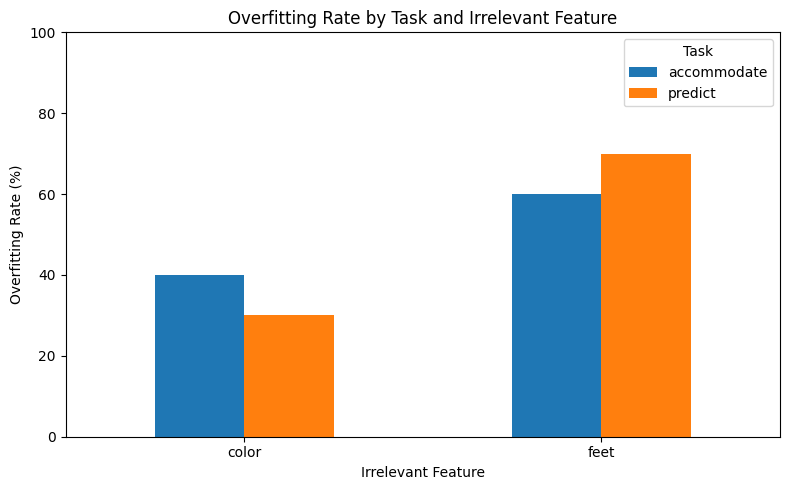

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Overfitting rate by task and irrelevant feature
overfit_summary = (
    df_params
    .groupby(['task', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

# Convert mean proportion to percent
overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100

print(overfit_summary)

#Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Pivot for grouped bar plot
plot_data = overfit_summary.pivot(
    index='irrelevant_dim',
    columns='task',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Task and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='Task')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure2OverfittingRateByTask.png'))
plt.show()

Part 2: Testing distribution of all model parameter scores by task

model_param_score         task irrelevant_dim    0    1    2
0                  accommodate          color  0.0  6.0  4.0
1                  accommodate           feet  0.0  4.0  6.0
2                      predict          color  2.0  5.0  3.0
3                      predict           feet  0.0  3.0  7.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37447/3367612162.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37447/3367612162.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


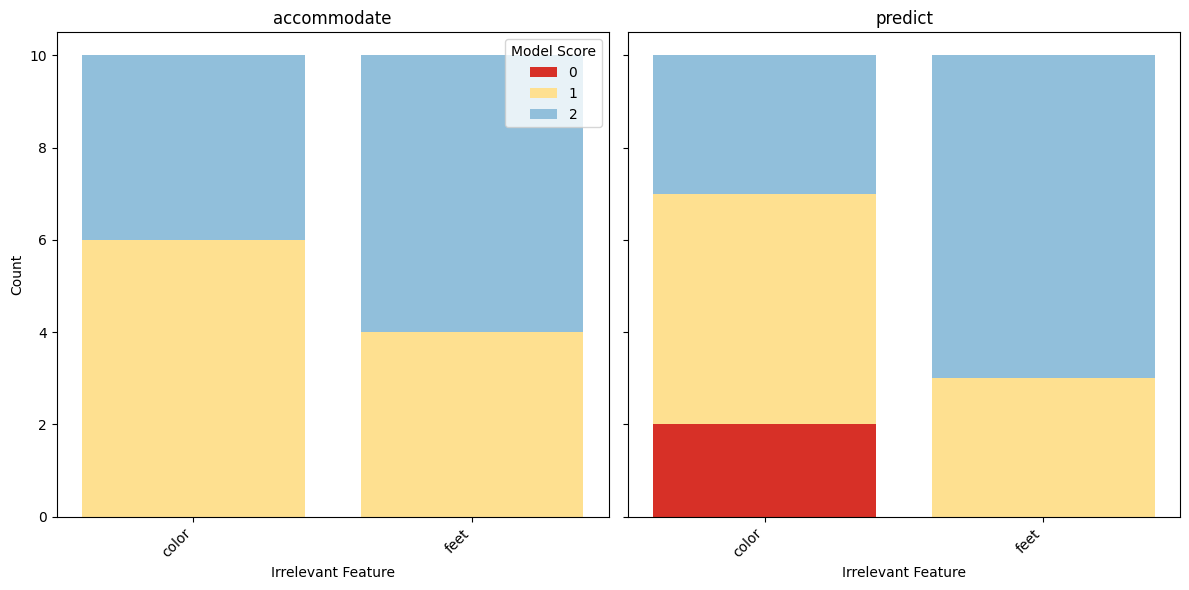

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os

df_params['task'] = df_params['task'].astype('category')

# Count occurrences of each model_param_score within each task × irrelevant feature
score_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

# Pivot so each score becomes a column
score_pivot = score_counts.pivot_table(
    index=['task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params['task'].cat.categories
buckets = [0, 1, 2]   # now only 3 possible scores with 2 features
colors = ['#d73027', '#fee090', '#91bfdb']  # one color per score

# Create subplots, one per task
fig, axes = plt.subplots(1, len(tasks), figsize=(12, 6), sharey=True)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    # Filter for this task
    task_data = score_pivot[score_pivot['task'] == task].copy()

    x = np.arange(len(task_data))
    bottom = np.zeros(len(task_data))

    for i, b in enumerate(buckets):
        values = task_data[b] if b in task_data.columns else np.zeros(len(task_data))
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=f"{b}" if ax == axes[0] else "",
            color=colors[i]
        )
        bottom += values.values if hasattr(values, "values") else values

    ax.set_xticks(x)
    ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
    ax.set_title(task)
    ax.set_xlabel("Irrelevant Feature")

axes[0].set_ylabel("Count")
axes[0].legend(title="Model Score")
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskAndIrrelevantFeature.png'))
plt.show()

In [25]:
contingency_all = pd.crosstab(
    df_params['task'],
    df_params['model_param_score']
)

print(contingency_all)

chi2, p, dof, expected = chi2_contingency(contingency_all)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

ax = contingency_all.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel("Task")
ax.set_ylabel("Count")
#ax.set_title("Model Parameter Scores by Task")

# Add numerical labels with the count
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=9
    )
plt.legend(title="Model parameter score", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
'''
plt.savefig(
    os.path.join(outputdir, "Figure2_TaskByModelParamScore_StackedBars.png"),
    dpi=300
)
'''
plt.close()

#Function of condition, wing relevance, and wing direction - the full distribution across that 
#code explanations later


model_param_score  0   1   2
task                        
accommodate        0  10  10
predict            2   8  10
Chi-square = 2.222
df = 2
p-value = 0.3292


**Primary Analysis #2: Predicting Feature Importance Ratings**

In [27]:
#Create map from short codes to feature descriptions

feet_map = {
    'round': 'f',
    'curly/pointy': 'c'
}

color_map = {
    'red': 'y',
    'green': 'g'
}



feature_maps = {
    'feet': feet_map,
    'color': color_map
}


In [28]:
#Compute feature importance scores

from doctest import debug


def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['feet', 'color']
    
    def compute_row_importance(row, feat):
        disc = row[f'{feat}_discrete_slider.response']
        dirc = row[f'{feat}_direction_slider.response']
        cont = row[f'{feat}_continuous_slider.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        

        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)
if debug:
    print(df_combined['feet_importance'])

response: 'round' internal: 'f' high: 'c' low: 'f'
in negative
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'c' low: 'f'
in negative
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' in

In [31]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'color_importance',
    'relevant_dim', 'irrelevant_dim', 'feet_high','color_high', 'feet_discrete_slider.response'
]

df_long = df_combined[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high', 'feet_discrete_slider.response'],
    value_vars=['feet_importance', 'color_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)

print(df_long.tail(20))

    participant     task relevant_dim irrelevant_dim color_high feet_high  \
60           21  predict        color           feet          G         C   
61           22  predict        color           feet          Y         F   
62           23  predict        color           feet          Y         C   
63           24  predict         feet          color          Y         C   
64           25  predict        color           feet          Y         C   
65           26  predict         feet          color          G         C   
66           27  predict         feet          color          Y         F   
67           28  predict         feet          color          Y         F   
68           29  predict         feet          color          Y         C   
69           30  predict         feet          color          G         F   
70           31  predict         feet          color          Y         F   
71           32  predict        color           feet          G         C   

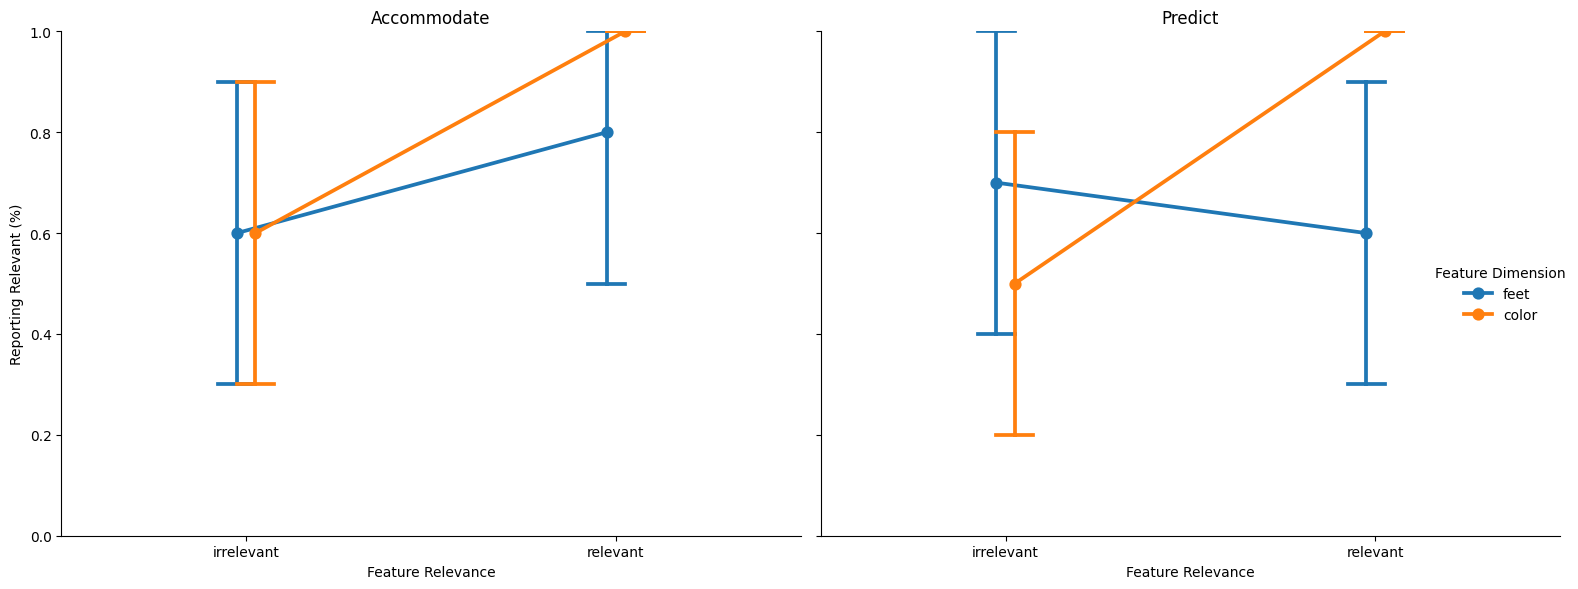

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

df_long['reported_relevant'] = (df_long['feature_importance'] != 0).astype(int)

g = sns.catplot(
    data=df_long,
    x="feature_relevance",
    y="reported_relevant",
    hue="feature_dimension",
    col="task",
    kind="point",
    dodge=True,
    capsize=0.1,
    markers="o",
    height=6,
    aspect=1.2
)

# y-axis is proportion
g.set(ylim=(0, 1))

g.set_axis_labels("Feature Relevance", "Reporting Relevant (%)")

# nicer subplot titles
for ax in g.axes.flatten():
    ax.set_title(ax.get_title().split(' = ')[-1].capitalize())

g._legend.set_title("Feature Dimension")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure_RelevanceReportingByRelevantFeature.png'))
plt.show()

In [35]:
print(df_long.groupby('feature_dimension')['feature_relevance'].describe())

                  count unique         top freq
feature_dimension                              
bright               40      1  irrelevant   40
color                40      2    relevant   20
feet                 40      2  irrelevant   20


FEET — relevant: 20 points
FEET — irrelevant: 20 points
COLOR — relevant: 20 points
COLOR — irrelevant: 20 points


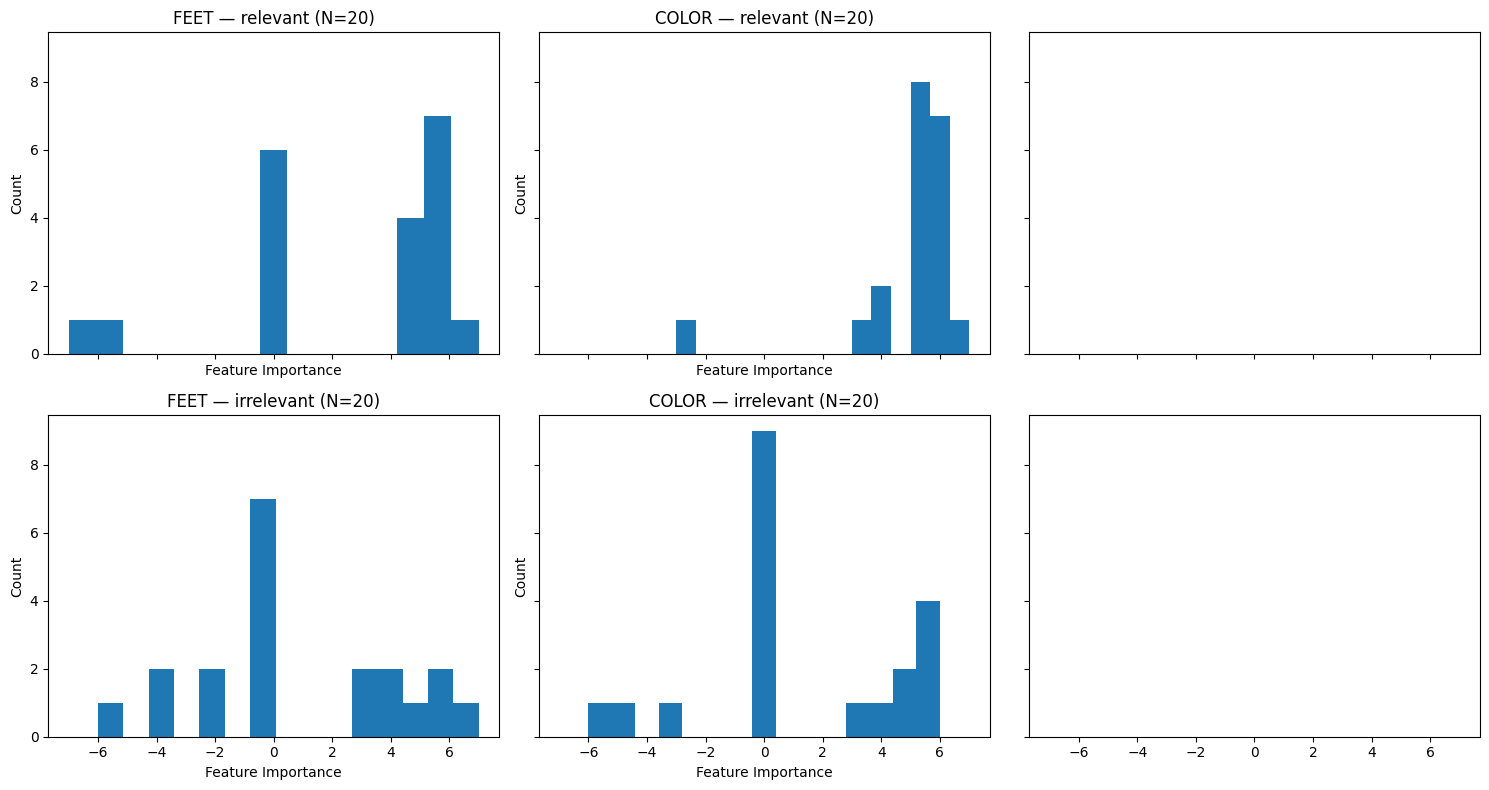

In [33]:
import matplotlib.pyplot as plt

features = ['feet', 'color']
relevance_states = ['relevant', 'irrelevant']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):
        
        ax = axes[row, col]
        
        subset = df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ]
        
        # Number of rows in this subset
        n_points = len(subset)
        print(f"{feat.upper()} — {rel}: {n_points} points")
        
        ax.hist(subset['feature_importance'], bins=15, density=False)
        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceScoresbyFeature.png'))
plt.show()


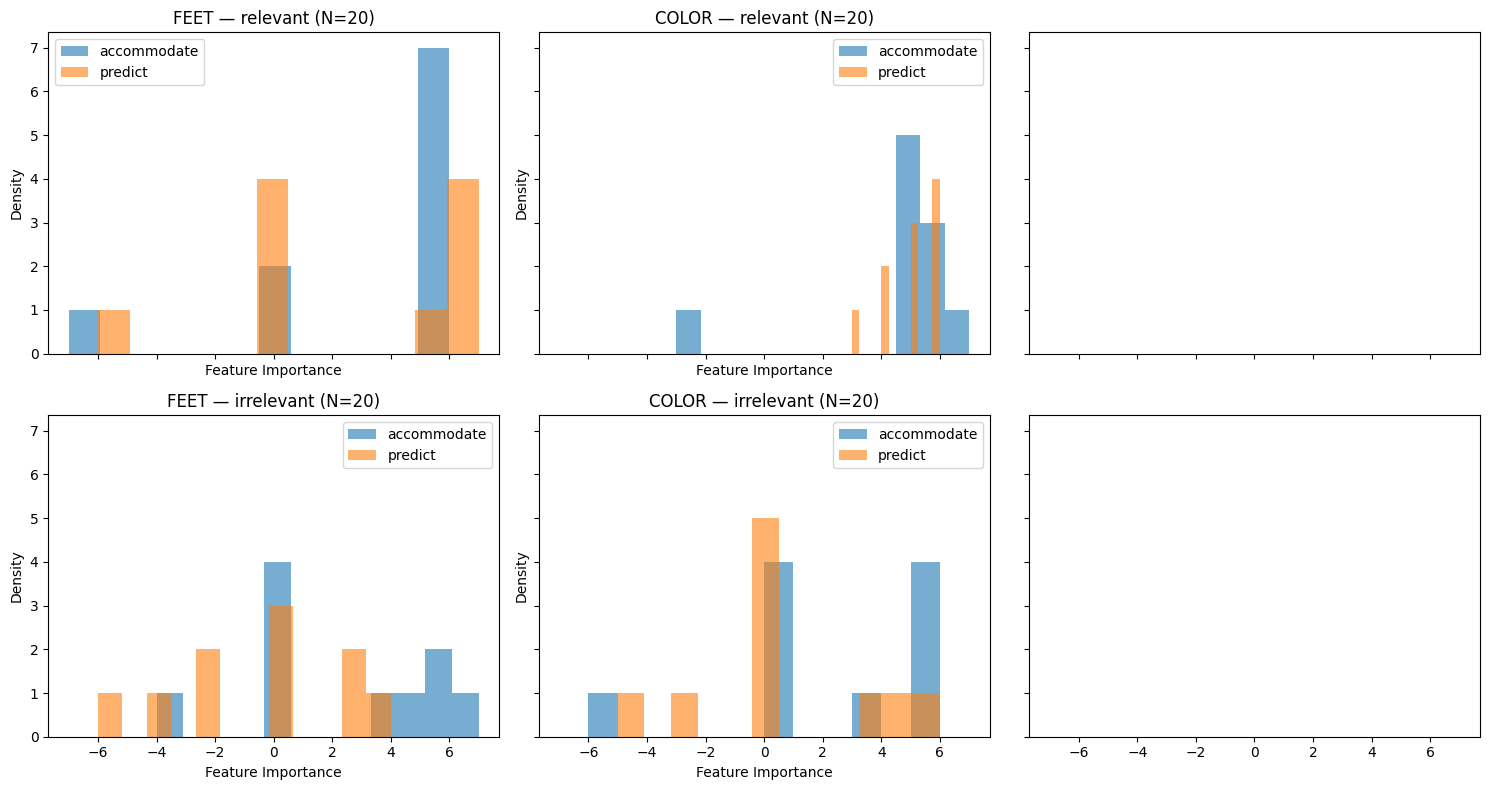

In [34]:
import matplotlib.pyplot as plt

features = ['feet', 'color']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

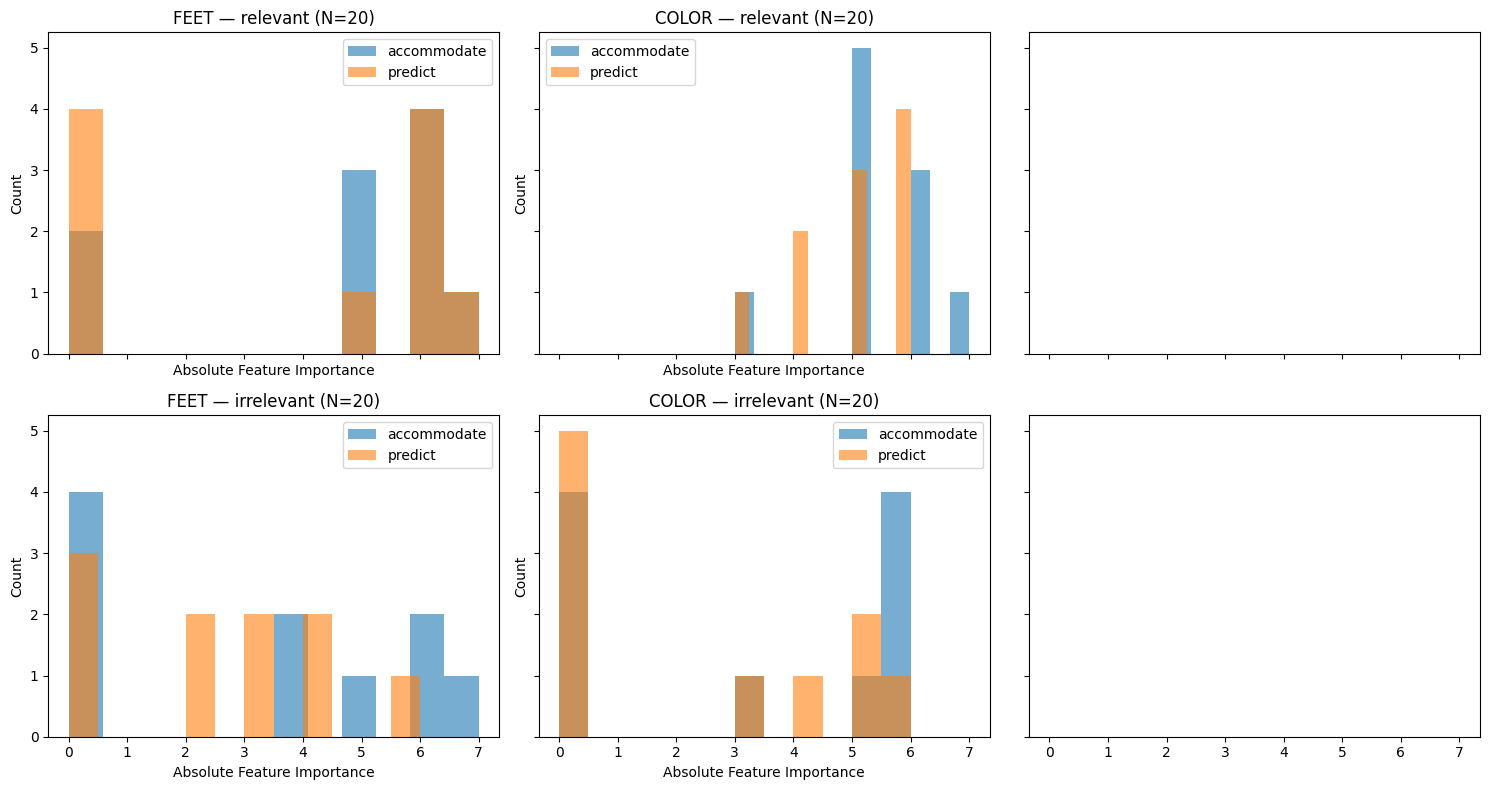

In [35]:
df_long['abs_feature_importance'] = df_long['feature_importance'].abs()
import matplotlib.pyplot as plt
import os

features = ['feet', 'color']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['abs_feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Absolute Feature Importance")
        ax.set_ylabel("Count")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'AbsoluteFeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

In [36]:
pd.crosstab(df_long['feature_relevance'], df_long['reported_relevant'])

reported_relevant,0,1
feature_relevance,,
irrelevant,16,24
relevant,6,34


In [37]:
import statsmodels.formula.api as smf

model = smf.logit(
    "reported_relevant ~ task + feature_relevance + feature_dimension",
    data=df_long
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.539295
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:      reported_relevant   No. Observations:                   80
Model:                          Logit   Df Residuals:                       76
Method:                           MLE   Df Model:                            3
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.08309
Time:                        09:13:15   Log-Likelihood:                -43.144
converged:                       True   LL-Null:                       -47.054
Covariance Type:            nonrobust   LLR p-value:                   0.04989
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.8293      0.510      1.625      0.

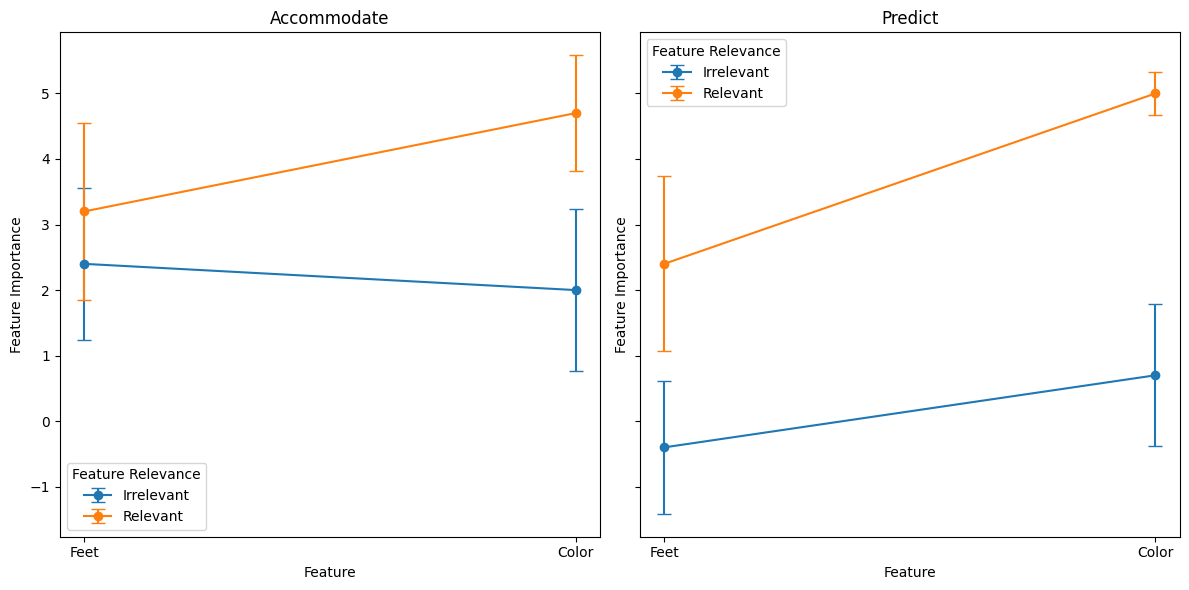

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import os

features = ['feet', 'color']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, task in enumerate(df_long["task"].unique()):
    ax = axes[i]
    
    task_df = df_long[df_long["task"] == task]

    for rel in ['irrelevant', 'relevant']:
        rel_df = task_df[task_df["feature_relevance"] == rel]
        
        means = []
        ses = []

        for feat in features:
            cell = rel_df[rel_df["feature_dimension"] == feat]["feature_importance"]
            
            means.append(cell.mean())
            ses.append(cell.std(ddof=1) / np.sqrt(len(cell)) if len(cell) > 1 else 0)

        label = rel.capitalize()
        ax.errorbar(
            range(len(features)),
            means,
            yerr=ses,
            marker='o',
            capsize=5,
            label=label
        )

    ax.set_title(task.capitalize())
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([f.capitalize() for f in features])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature Importance")
    ax.legend(title="Feature Relevance")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure5FeatureImportanceByTaskAndRelevance.png'))
plt.show()

In [66]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "feature_importance ~ task + feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStatsMaineffect.csv"))


                 Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   feature_importance
No. Observations:     80        Method:               REML              
No. Groups:           40        Scale:                10.2448           
Min. group size:      2         Log-Likelihood:       -209.9432         
Max. group size:      2         Converged:            Yes               
Mean group size:      2.0                                               
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      1.750    0.691  2.532 0.011  0.395  3.105
task[T.predict]               -1.150    0.836 -1.375 0.169 -2.789  0.489
feature_relevance[T.relevant]  2.650    0.716  3.703 0.000  1.247  4.053
Group Var                      1.872    0.704                        

In [ ]:
import statsmodels.formula.api as smf

#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStats.csv"))


                         Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         feature_importance
No. Observations:         80              Method:                     REML              
No. Groups:               40              Scale:                      10.0881           
Min. group size:          2               Log-Likelihood:             -207.8727         
Max. group size:          2               Converged:                  Yes               
Mean group size:          2.0                                                           
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      2.200    0.776  2.836 0.005  0.679  3.721
task[T.predict]                               -

In [57]:
irrelevant = df_long[df_long.feature_relevance == "irrelevant"]

model = smf.mixedlm(
    "feature_importance ~ task",
    irrelevant,
    groups=irrelevant["participant"]
).fit()

print(model.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: feature_importance
No. Observations: 40      Method:             REML              
No. Groups:       40      Scale:              6.1020            
Min. group size:  1       Log-Likelihood:     -104.4488         
Max. group size:  1       Converged:          Yes               
Mean group size:  1.0                                           
-----------------------------------------------------------------
                  Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------------
Intercept          2.200     0.388   5.677  0.000   1.440   2.960
task[T.predict]   -2.050     0.291  -7.053  0.000  -2.620  -1.480
Group Var          6.102                                         



/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [67]:
means = (
    df_long
    .groupby(["task", "feature_dimension", "feature_relevance"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


          task feature_dimension feature_relevance  mean       std  count
0  accommodate             color        irrelevant   2.0  3.915780     10
1  accommodate             color          relevant   4.7  2.790858     10
2  accommodate              feet        irrelevant   2.4  3.657564     10
3  accommodate              feet          relevant   3.2  4.289522     10
4      predict             color        irrelevant   0.7  3.433495     10
5      predict             color          relevant   5.0  1.054093     10
6      predict              feet        irrelevant  -0.4  3.204164     10
7      predict              feet          relevant   2.4  4.221637     10


In [68]:
means = (
    df_long
    .groupby(["task", "feet_high", "relevant_dim"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


          task feet_high relevant_dim  mean       std  count
0  accommodate         C        color   2.9  3.784471     10
1  accommodate         C         feet   3.4  2.951459     10
2  accommodate         F        color   4.2  2.973961     10
3  accommodate         F         feet   1.8  4.939636     10
4      predict         C        color   3.0  3.333333     10
5      predict         C         feet   2.9  3.107339     10
6      predict         F        color   1.6  3.921451     10
7      predict         F         feet   0.2  4.184628     10


In [ ]:
df_color = df_long[df_long["feature_dimension"] == "color"].copy()
df_color["color_relevant"] = (df_color["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_color["color_high"] = (df_color["color_high"] == "B").astype(int) #Code having a wing as 0/1
df_tail = df_long[df_long["feature_dimension"] == "tail"].copy()
df_tail["tail_relevant"] = (df_tail["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_tail["tail_high"] = (df_tail["tail_high"] == "C").astype(int) #Code having a wing as 0/1

     participant         task relevant_dim_1 relevant_dim_2 irrelevant_dim  \
418            1  accommodate           tail          color           wing   
419            2  accommodate          color           wing           tail   
420            3  accommodate          color           tail           wing   
421            4  accommodate          color           tail           wing   
422            5  accommodate          color           tail           wing   
..           ...          ...            ...            ...            ...   
831          414      predict          color           wing           tail   
832          415      predict           tail          color           wing   
833          416      predict          color           tail           wing   
834          417      predict          color           tail           wing   
835          418      predict          color           tail           wing   

    wing_high  color_high tail_high wing_discrete_slider.respon

In [115]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "feature_importance ~ task + tail_relevant + tail_high + task:tail_relevant + task:tail_high + tail_relevant:tail_high + task:tail_relevant:tail_high",
    df_tail,
    groups=df_tail["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStatsTail.csv"))


                         Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        feature_importance
No. Observations:          418            Method:                    REML              
No. Groups:                418            Scale:                     6.5715            
Min. group size:           1              Log-Likelihood:            -1124.8893        
Max. group size:           1              Converged:                 Yes               
Mean group size:           1.0                                                         
---------------------------------------------------------------------------------------
                                        Coef.     Std.Err.     z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                1.579         0.832  1.898 0.058 -0.051  3.209
task[T.predict]                         -1.579         1.

In [117]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "feature_importance ~ task + color_relevant + color_high + task:color_relevant + task:color_high + color_relevant:color_high + task:color_relevant:color_high",
    df_color,
    groups=df_color["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStatsColor.csv"))

                       Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       feature_importance
No. Observations:         418           Method:                   REML              
No. Groups:               418           Scale:                    5.3533            
Min. group size:          1             Log-Likelihood:           -1082.9187        
Max. group size:          1             Converged:                Yes               
Mean group size:          1.0                                                       
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.741    0.630  1.176 0.239 -0.493  1.975
task[T.predict]                            1.000    0.831  1.203 0.229 -0.629  2.629
colo

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [256]:
import statsmodels.formula.api as smf
import os

model = smf.ols(
    formula="""
        feature_importance ~ task * wing_relevant * wing_high
    """,
    data=df_wing
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     feature_importance   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     8.271
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           1.89e-09
Time:                        13:30:28   Log-Likelihood:                -1092.8
No. Observations:                 418   AIC:                             2202.
Df Residuals:                     410   BIC:                             2234.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [32]:
subset = df_wing[
    (df_wing["wing_high"] == 1) &
    (df_wing["wing_relevant"] == 1)
]

model_task = smf.ols(
    "feature_importance ~ task",
    data=subset
).fit()

print(model_task.summary())


                            OLS Regression Results                            
Dep. Variable:     feature_importance   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     4.376
Date:                Fri, 13 Feb 2026   Prob (F-statistic):             0.0389
Time:                        10:51:32   Log-Likelihood:                -246.93
No. Observations:                 104   AIC:                             497.9
Df Residuals:                     102   BIC:                             503.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.1346      0.364     

In [37]:
df_wingAbs = df_wing.copy()
df_wingAbs["abs_feature_importance"] = df_wingAbs["feature_importance"].abs()

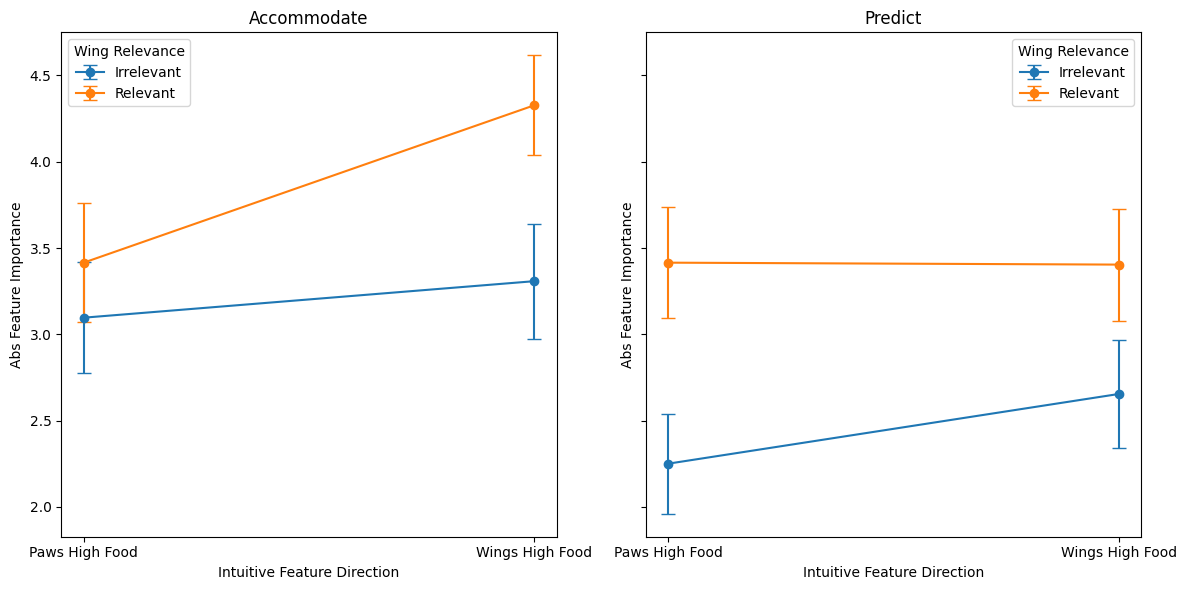

In [38]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12,6), sharey=True)

for i, task in enumerate(df_wingAbs["task"].unique()):
    ax = axes[i]
    
    task_df = df_wingAbs[df_wingAbs["task"] == task]

    for rel in [0, 1]:  # irrelevant / relevant
        rel_df = task_df[task_df["wing_relevant"] == rel]
        
        means = []
        ses = []

        for present in [0, 1]:  # paws high / wings high
            cell = rel_df[rel_df["wing_high"] == present]["abs_feature_importance"]
            
            means.append(cell.mean())
            ses.append(cell.std() / np.sqrt(len(cell)))

        label = "Relevant" if rel == 1 else "Irrelevant"
        ax.errorbar([0,1], means, yerr=ses, marker='o', capsize=5, label=label)

    ax.set_title(task.capitalize())
    ax.set_xticks([0,1])
    ax.set_xticklabels(["Paws High Food", "Wings High Food"])
    ax.set_xlabel("Intuitive Feature Direction")
    ax.set_ylabel("Abs Feature Importance")
    ax.legend(title="Wing Relevance")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure6WingAbsFeatureImportanceByTask.png'))
plt.show()

In [39]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "abs_feature_importance ~ task + wing_relevant + wing_high + task:wing_relevant + task:wing_high + wing_relevant:wing_high + task:wing_relevant:wing_high",
    df_wingAbs,
    groups=df_wingAbs["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure6mixedlm_absfeatureimportance.csv"))

                      Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     abs_feature_importance
No. Observations:       418         Method:                 REML                  
No. Groups:             418         Scale:                  2.6498                
Min. group size:        1           Log-Likelihood:         -939.4511             
Max. group size:        1           Converged:              Yes                   
Mean group size:        1.0                                                       
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                3.096    0.265 11.677 0.000  2.576  3.616
task[T.predict]                         -0.846    0.292 -2.899 0.004 -1.418 -0.274
wing_relevant              

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [252]:
import statsmodels.formula.api as smf
import os

model = smf.ols(
    formula="""
        abs_feature_importance ~ task * wing_relevant * wing_high
    """,
    data=df_wingAbs
).fit()

print(model.summary())


                              OLS Regression Results                              
Dep. Variable:     abs_feature_importance   R-squared:                       0.059
Model:                                OLS   Adj. R-squared:                  0.043
Method:                     Least Squares   F-statistic:                     3.672
Date:                    Thu, 12 Feb 2026   Prob (F-statistic):           0.000734
Time:                            13:26:59   Log-Likelihood:                -937.61
No. Observations:                     418   AIC:                             1891.
Df Residuals:                         410   BIC:                             1924.
Df Model:                               7                                         
Covariance Type:                nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [269]:
subset = df_wingAbs[
    (df_wingAbs["wing_high"] == 1) &
    (df_wingAbs["wing_relevant"] == 1)
]

model_task = smf.ols(
    "abs_feature_importance ~ task",
    data=subset
).fit()

print(model_task.summary())


                              OLS Regression Results                              
Dep. Variable:     abs_feature_importance   R-squared:                       0.042
Model:                                OLS   Adj. R-squared:                  0.033
Method:                     Least Squares   F-statistic:                     4.502
Date:                    Thu, 12 Feb 2026   Prob (F-statistic):             0.0363
Time:                            13:35:27   Log-Likelihood:                -229.42
No. Observations:                     104   AIC:                             462.8
Df Residuals:                         102   BIC:                             468.1
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
In

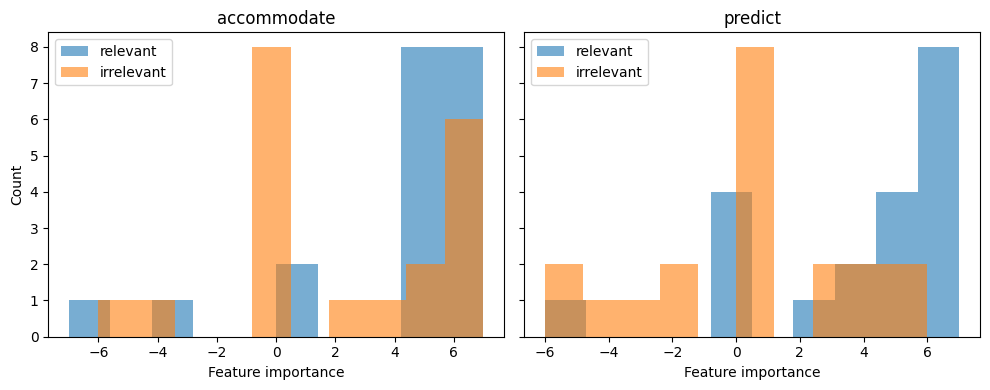

In [69]:
tasks = df_long['task'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tasks),
    figsize=(5 * len(tasks), 4),
    sharey=True
)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    for label in ['relevant', 'irrelevant']:
        values = df_long.loc[
            (df_long['task'] == task) &
            (df_long['feature_relevance'] == label),
            'feature_importance'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=label)

    ax.set_title(task)
    ax.set_xlabel("Feature importance")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3_FeatureImportanceByTaskAndRelevance.png'), dpi=300)
plt.show()


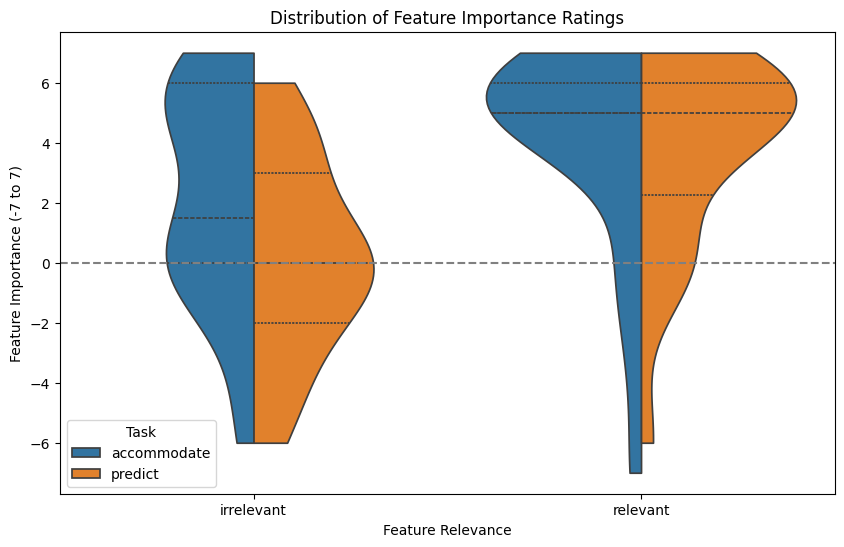

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()


In [72]:
df_long['task'] = df_long['task'].astype('category')  # predict/accomodate
df_long['feature_dimension'] = df_long['feature_dimension'].astype('category')
df_long['feature_relevance'] = df_long['feature_relevance'].astype('category')


In [73]:
import statsmodels.formula.api as smf

# Predicting feature importance from task and feature relevance, with random intercepts for participants
md = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"],  # random intercept per participant
    re_formula="~feature_relevance" # random slopes
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_featureimportance.csv"))

                         Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         feature_importance
No. Observations:         80              Method:                     REML              
No. Groups:               40              Scale:                      7.2500            
Min. group size:          2               Log-Likelihood:             -207.8690         
Max. group size:          2               Converged:                  Yes               
Mean group size:          2.0                                                           
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      2.200    0.781  2.816 0.005  0.669  3.731
task[T.predict]                               -

In [42]:
#Analyse the absolute value of feature importance ratings (ignoring direction)
df_longAbs = df_long.copy()
df_longAbs["abs_feature_importance"] = df_longAbs["feature_importance"].abs()
avg_importance_task = (
    df_longAbs
        .groupby(['task', 'feature_relevance'])['abs_feature_importance']
        .mean()
        .reset_index()
)
print(avg_importance_task)
avg_importance_relevance = (
    df_longAbs
        .groupby(['feature_relevance'])['abs_feature_importance']
        .mean()
        .reset_index()
)

print(avg_importance_relevance)

avg_importance_feature = (
    df_longAbs
        .groupby(['feature_dimension'])['abs_feature_importance']
        .mean()
        .reset_index()
)
print(avg_importance_feature)

          task feature_relevance  abs_feature_importance
0  accommodate        irrelevant                3.063636
1  accommodate          relevant                3.684091
2      predict        irrelevant                2.721461
3      predict          relevant                3.449772
  feature_relevance  abs_feature_importance
0        irrelevant                2.892938
1          relevant                3.567198
  feature_dimension  abs_feature_importance
0             color                3.248292
1              tail                3.405467
2              wing                3.373576


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11746/1409563864.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'feature_relevance'])['abs_feature_importance']
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11746/1409563864.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['feature_relevance'])['abs_feature_importance']
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11746/1409563864.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

In [44]:
df_irrel = df_longAbs[df_longAbs["feature_relevance"] == "irrelevant"].copy()

accom_vals = df_irrel[df_irrel["task"]=="accommodate"]["abs_feature_importance"]
predict_vals = df_irrel[df_irrel["task"]=="predict"]["abs_feature_importance"]
mean_accom = np.mean(accom_vals)
mean_predict = np.mean(predict_vals)

print(f"Mean (accommodate) = {mean_accom:.3f}")
print(f"Mean (predict) = {mean_predict:.3f}")
t, p = ttest_ind(predict_vals, accom_vals, equal_var=False)  # Welch's t-test
print(f"t = {t:.3f}, p = {p:.4f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_feature_importance": [mean_accom, mean_predict],
    "t_stat": [t, t], 
    "p_value": [p, p]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_abs_featureimportance.csv"))

Mean (accommodate) = 3.064
Mean (predict) = 2.721
t = -1.571, p = 0.1170


**Analysis 3: Predicting Food Consumption Ratings**

In [78]:
#Group by average food amount per item in training
df = df_combined[['task', 'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2 = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.head(20))


           task  conditionOrder item fertility_score
0   accommodate               1  G_C             8.0
1   accommodate               1  G_F            3.25
2   accommodate               1  Y_C            6.25
3   accommodate               1  Y_F             3.0
4   accommodate               2  G_C             8.5
5   accommodate               2  G_F            7.75
6   accommodate               2  Y_C             2.0
7   accommodate               2  Y_F            3.75
8   accommodate               3  G_C            4.75
9   accommodate               3  G_F            6.25
10  accommodate               3  Y_C            3.75
11  accommodate               3  Y_F            8.25
12  accommodate               4  G_C            2.75
13  accommodate               4  G_F             4.0
14  accommodate               4  Y_C             8.0
15  accommodate               4  Y_F             8.5
16  accommodate               5  G_C             8.5
17  accommodate               5  G_F          

In [79]:
#Get food consumption ratings by item

df = df_combined[['task', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)


           task  conditionOrder item testing_responses relevant_dim  \
0   accommodate               6  Y_F               3.0        color   
0   accommodate               6  G_F               8.0        color   
0   accommodate               6  Y_C               4.0        color   
0   accommodate               6  G_C               9.0        color   
1   accommodate               3  G_F               5.0         feet   
..          ...             ...  ...               ...          ...   
38      predict              20  Y_F               9.0        color   
39      predict              18  G_F               5.0        color   
39      predict              18  Y_C               4.0        color   
39      predict              18  Y_F               4.0        color   
39      predict              18  G_C               5.0        color   

   irrelevant_dim color_high feet_high  
0            feet          G         C  
0            feet          G         C  
0            feet       

In [82]:
#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)

            task  conditionOrder item testing_responses relevant_dim  \
0    accommodate               6  Y_F               3.0        color   
1    accommodate               6  G_F               8.0        color   
2    accommodate               6  Y_C               4.0        color   
3    accommodate               6  G_C               9.0        color   
4    accommodate               3  G_F               5.0         feet   
..           ...             ...  ...               ...          ...   
155      predict              20  Y_F               9.0        color   
156      predict              18  G_F               5.0        color   
157      predict              18  Y_C               4.0        color   
158      predict              18  Y_F               4.0        color   
159      predict              18  G_C               5.0        color   

    irrelevant_dim color_high feet_high fertility_score error abs_error color  \
0             feet          G         C            3.2

In [45]:
print(df_merged[['food_amount', 'testing_responses', 'error']])

     food_amount testing_responses     error
0       6.666667               7.0  0.333333
1       4.333333               6.0  1.666667
2            6.0               6.0       0.0
3       3.333333               3.0 -0.333333
4            8.0               7.0      -1.0
...          ...               ...       ...
3339    5.666667               8.0  2.333333
3340    4.333333               6.0  1.666667
3341         8.0               5.0      -3.0
3342    6.333333               6.0 -0.333333
3343    2.333333               4.0  1.666667

[3344 rows x 3 columns]


In [47]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['wing', 'color', 'tail']] = df_merged['item'].str.split('_', expand=True)

print("Mean error by tail:")
print(df_merged.groupby('tail')['error'].mean())

print("Mean error by color:")
print(df_merged.groupby('color')['error'].mean())

print("Mean error by wing:")
print(df_merged.groupby('wing')['error'].mean())
#t-test: color 1 vs color 2 absolute error 
color1 = df_merged.loc[df_merged['wing'] == 'N', 'error']
color2 = df_merged.loc[df_merged['wing'] == 'T', 'error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(color1), pd.to_numeric(color2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean error by tail:
tail
C    0.393939
S   -0.022329
Name: error, dtype: object
Mean error by color:
color
B       0.125
Y    0.246611
Name: error, dtype: object
Mean error by wing:
wing
N   -0.058612
T    0.430223
Name: error, dtype: object
T = -8.557, p = 0.000


S
C


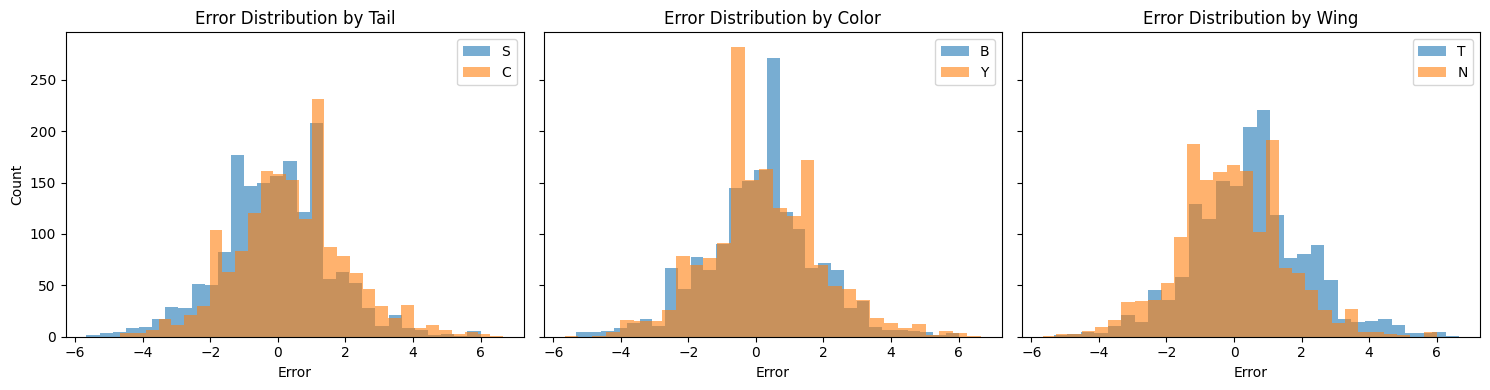

In [280]:
import matplotlib.pyplot as plt

# Make sure error is numeric
df_merged['error'] = pd.to_numeric(df_merged['error'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Tail
for t in df_merged['tail'].unique():
    print(t)
    axes[0].hist(
        df_merged.loc[df_merged['tail'] == t, 'error'],
        bins=30,
        alpha=0.6,
        label=t
    )
axes[0].set_title('Error Distribution by Tail')
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Color ---
for c in df_merged['color'].unique():
    axes[1].hist(
        df_merged.loc[df_merged['color'] == c, 'error'],
        bins=30,
        alpha=0.6,
        label=c
    )
axes[1].set_title('Error Distribution by Color')
axes[1].set_xlabel('Error')
axes[1].legend()

# --- Wing ---
for w in df_merged['wing'].unique():
    axes[2].hist(
        df_merged.loc[df_merged['wing'] == w, 'error'],
        bins=30,
        alpha=0.6,
        label=w
    )
axes[2].set_title('Error Distribution by Wing')
axes[2].set_xlabel('Error')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure7_ErrorDistributionByFeature.png'), dpi=300)
plt.show()


In [83]:
print(df_merged)

            task  conditionOrder item testing_responses relevant_dim  \
0    accommodate               6  Y_F               3.0        color   
1    accommodate               6  G_F               8.0        color   
2    accommodate               6  Y_C               4.0        color   
3    accommodate               6  G_C               9.0        color   
4    accommodate               3  G_F               5.0         feet   
..           ...             ...  ...               ...          ...   
155      predict              20  Y_F               9.0        color   
156      predict              18  G_F               5.0        color   
157      predict              18  Y_C               4.0        color   
158      predict              18  Y_F               4.0        color   
159      predict              18  G_C               5.0        color   

    irrelevant_dim color_high feet_high fertility_score error abs_error color  \
0             feet          G         C            3.2

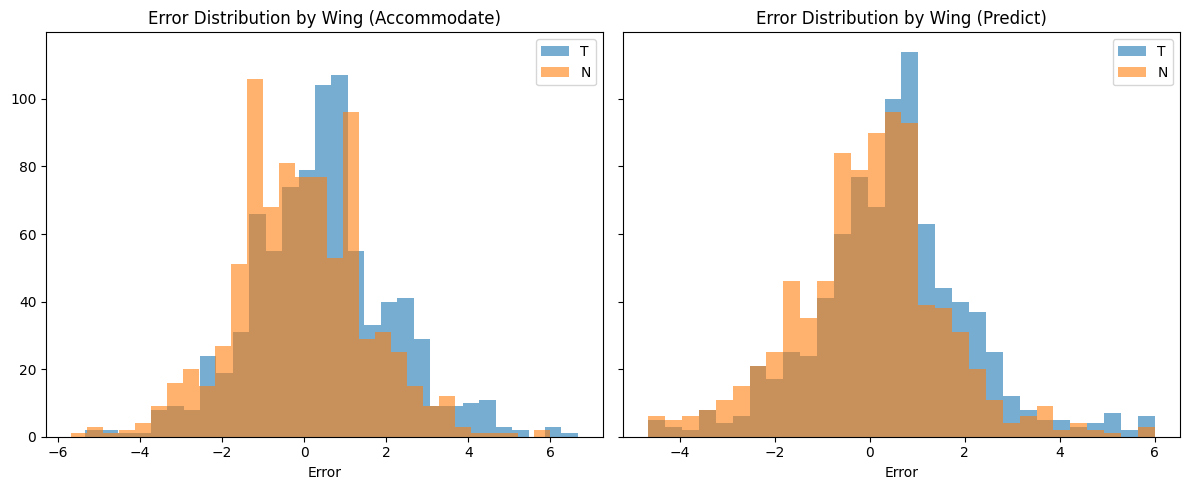

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, task in enumerate(['accommodate', 'predict']):
    for w in df_merged['wing'].unique():
        axes[i].hist(
            df_merged.loc[(df_merged['wing'] == w) & (df_merged['task'] == task), 'error'],
            bins=30,
            alpha=0.6,
            label=w
        )
    axes[i].set_title(f'Error Distribution by Wing ({task.capitalize()})')
    axes[i].set_xlabel('Error')
    axes[i].legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure7b_ErrorDistributionByWingAndTask.png'), dpi=300)
plt.show()

In [281]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['wing', 'color', 'tail']] = df_merged['item'].str.split('_', expand=True)

print("Mean abs_error by tail:")
print(df_merged.groupby('tail')['abs_error'].mean())

print("Mean abs_error by color:")
print(df_merged.groupby('color')['abs_error'].mean())

print("Mean abs_error by wing:")
print(df_merged.groupby('wing')['abs_error'].mean())
#t-test: color 1 vs color 2 absolute error 
color1 = df_merged.loc[df_merged['color'] == 'B', 'abs_error']
color2 = df_merged.loc[df_merged['color'] == 'Y', 'abs_error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(color1), pd.to_numeric(color2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean abs_error by tail:
tail
C    1.305024
S     1.24681
Name: abs_error, dtype: object
Mean abs_error by color:
color
B    1.262161
Y    1.289673
Name: abs_error, dtype: object
Mean abs_error by wing:
wing
N    1.227671
T    1.324163
Name: abs_error, dtype: object
T = -0.728, p = 0.467


In [282]:
#t-test: predict vs accomodate absolute error
df_merged['abs_error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['abs_error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'abs_error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'abs_error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    1.287879
predict        1.263955
Name: abs_error, dtype: float64
T = 0.633, p = 0.527


Part 2: Correlations

In [84]:
print(df_merged.head(20))

           task  conditionOrder item testing_responses relevant_dim  \
0   accommodate               6  Y_F               3.0        color   
1   accommodate               6  G_F               8.0        color   
2   accommodate               6  Y_C               4.0        color   
3   accommodate               6  G_C               9.0        color   
4   accommodate               3  G_F               5.0         feet   
5   accommodate               3  Y_C               3.0         feet   
6   accommodate               3  Y_F               3.0         feet   
7   accommodate               3  G_C               7.0         feet   
8   accommodate              15  G_F               9.0         feet   
9   accommodate              15  Y_C               3.0         feet   
10  accommodate              15  Y_F               6.0         feet   
11  accommodate              15  G_C               3.0         feet   
12  accommodate              11  G_C               4.0         feet   
13  ac

In [88]:
print(df_merged)

            task  conditionOrder item testing_responses relevant_dim  \
0    accommodate               6  Y_F               3.0        color   
1    accommodate               6  G_F               8.0        color   
2    accommodate               6  Y_C               4.0        color   
3    accommodate               6  G_C               9.0        color   
4    accommodate               3  G_F               5.0         feet   
..           ...             ...  ...               ...          ...   
155      predict              20  Y_F               9.0        color   
156      predict              18  G_F               5.0        color   
157      predict              18  Y_C               4.0        color   
158      predict              18  Y_F               4.0        color   
159      predict              18  G_C               5.0        color   

    irrelevant_dim color_high feet_high fertility_score error abs_error color  \
0             feet          G         C            3.2

In [92]:
# Columns indicating whether the item's feature is the "high" dimension (1 or 0 coding)
df_merged['color_match_high']  = (df_merged['color']  == df_merged['color_high']).astype(int)
df_merged['feet_match_high'] = (df_merged['feet'] == df_merged['feet_high']).astype(int)
#print(df_merged.head(20))
# Group by participant
participant_corrs = []

for pid, g in df_merged.groupby(['task', 'conditionOrder']):
    for feat in ['color','feet']:
        # Column indicating match to high value
        match_col = f"{feat}_match_high"
        
        # Compute correlation
        corr = g['testing_responses'].corr(g[match_col])
        
        # Determine if this feature is relevant for this participant
        relevant = g['relevant_dim'].iloc[0] == feat
        high_col  = f"{feat}_high"
        
        # Store
        participant_corrs.append({
            'participant': pid,
            'task': g['task'].iloc[0],
            'feature_dimension': feat,
            'high_value': g[high_col].iloc[0],
            'feature_relevance': 'relevant' if relevant else 'irrelevant',
            'correlation': corr,
            'irrelevant_dim': g['irrelevant_dim'].iloc[0],
            'abs_correlation': abs(corr) if pd.notna(corr) else None
        })

df_corr = pd.DataFrame(participant_corrs)
print(df_corr.tail(40))



      participant     task feature_dimension high_value feature_relevance  \
40   (predict, 1)  predict             color          G        irrelevant   
41   (predict, 1)  predict              feet          C          relevant   
42   (predict, 2)  predict             color          G          relevant   
43   (predict, 2)  predict              feet          F        irrelevant   
44   (predict, 3)  predict             color          Y        irrelevant   
45   (predict, 3)  predict              feet          F          relevant   
46   (predict, 4)  predict             color          Y          relevant   
47   (predict, 4)  predict              feet          F        irrelevant   
48   (predict, 5)  predict             color          G        irrelevant   
49   (predict, 5)  predict              feet          C          relevant   
50   (predict, 6)  predict             color          G          relevant   
51   (predict, 6)  predict              feet          C        irrelevant   

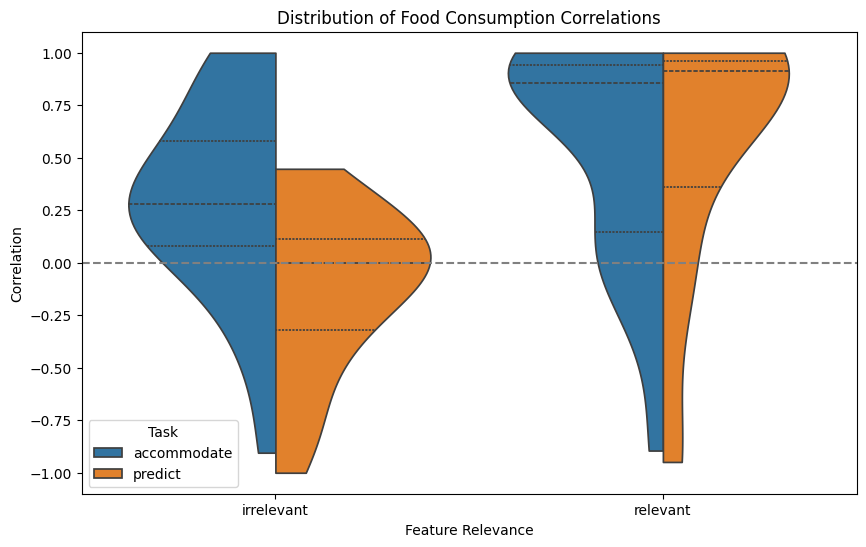

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_corr,
    x='feature_relevance',      # relevant / irrelevant
    y='correlation',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Food Consumption Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


In [95]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "correlation ~ task * feature_relevance",
    df_corr,
    groups=df_corr["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(
    os.path.join(outputdir, "Figure11_mixedlm_correlationStats.csv")
)

                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           correlation
No. Observations:            80                Method:                       REML       
No. Groups:                  40                Scale:                        0.2431     
Min. group size:             2                 Log-Likelihood:               -63.8005   
Max. group size:             2                 Converged:                    Yes        
Mean group size:             2.0                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      0.290    0.116  2.496 0.013  0.062  0.517
task[T.predict]                               -

In [78]:
df_wing2 = df_corr[df_corr["feature_dimension"] == "wing"].copy()
df_wing2["wing_relevant"] = (df_wing2["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_wing2["wing_present"] = (df_wing2["high_value"] == "T").astype(int) #Code relevancy as 0/1

print(df_wing2)

           participant         task feature_dimension high_value  \
2     (accommodate, 1)  accommodate              wing          T   
5     (accommodate, 3)  accommodate              wing          N   
8     (accommodate, 4)  accommodate              wing          T   
11    (accommodate, 5)  accommodate              wing          T   
14    (accommodate, 6)  accommodate              wing          T   
...                ...          ...               ...        ...   
1241    (predict, 216)      predict              wing          N   
1244    (predict, 217)      predict              wing          T   
1247    (predict, 218)      predict              wing          T   
1250    (predict, 219)      predict              wing          N   
1253    (predict, 220)      predict              wing          N   

     feature_relevance  correlation irrelevant_dim  abs_correlation  \
2             relevant     0.875190          color         0.875190   
5             relevant     1.000000      

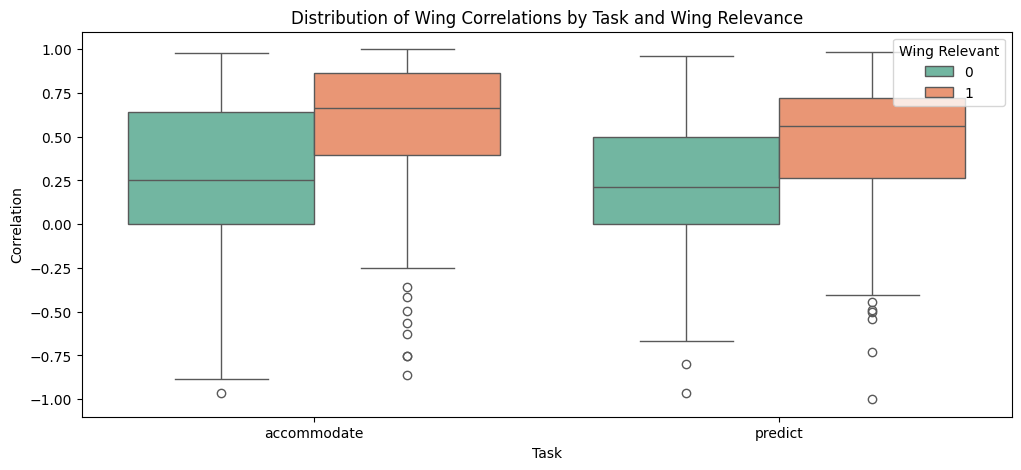

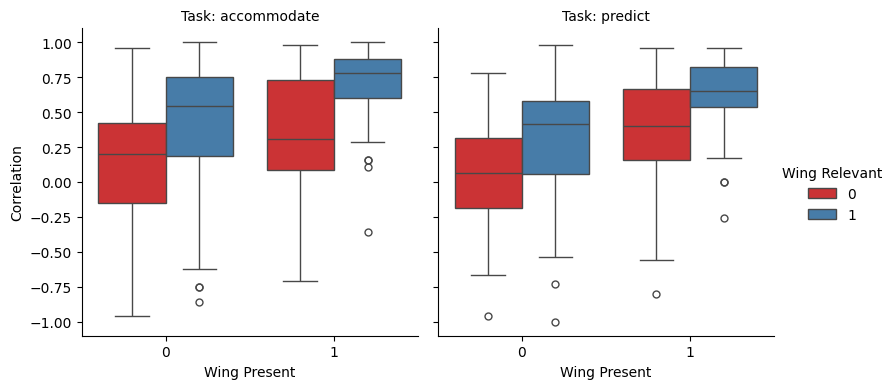

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure correlations are numeric
df_wing2['correlation'] = pd.to_numeric(df_wing2['correlation'], errors='coerce')

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_wing2,
    x='task',
    y='correlation',
    hue='wing_relevant',
    palette='Set2'
)
plt.title('Distribution of Wing Correlations by Task and Wing Relevance')
plt.ylabel('Correlation')
plt.xlabel('Task')
plt.legend(title='Wing Relevant', loc='upper right')
plt.show()

# Facet by wing_present 
g = sns.catplot(
    data=df_wing2,
    x='wing_present',
    y='correlation',
    hue='wing_relevant',
    col='task',
    kind='box',
    palette='Set1',
    height=4,
    aspect=1
)
g.set_axis_labels("Wing Present", "Correlation")
g.set_titles("Task: {col_name}")
g._legend.set_title("Wing Relevant")
plt.show()


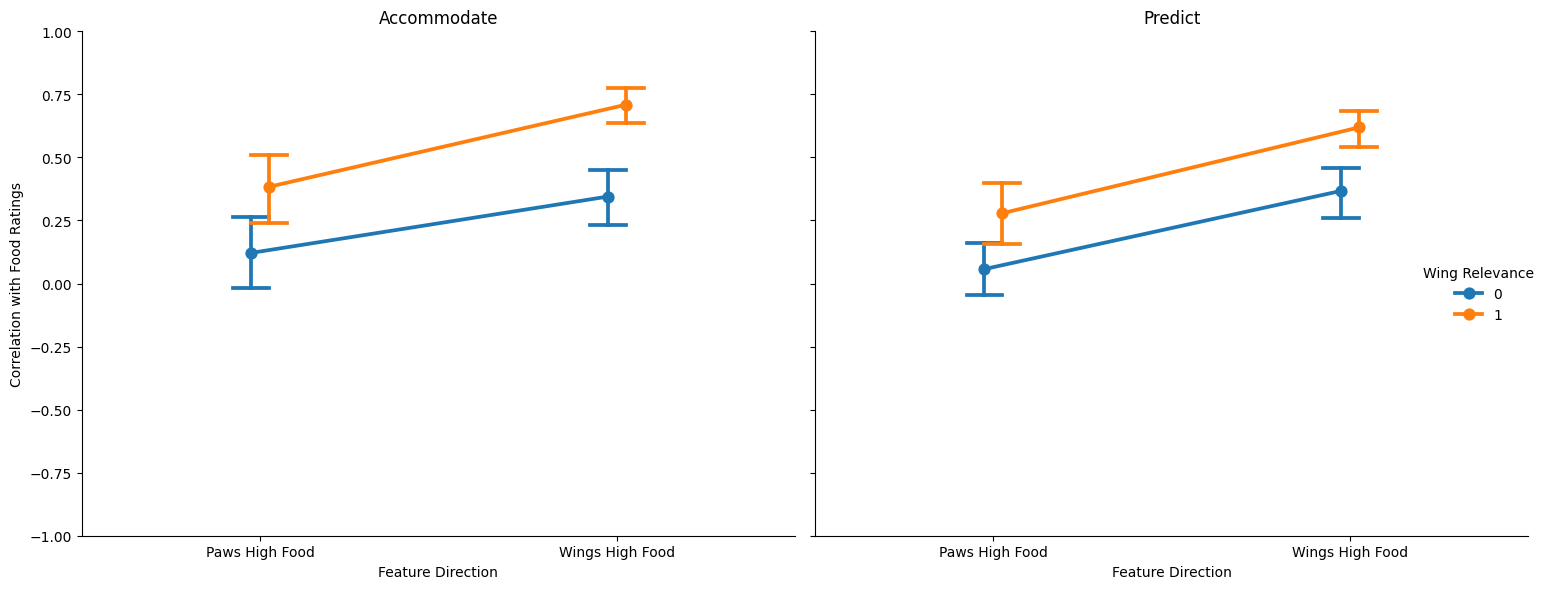

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

# Define x-axis labels
x_labels = ["Paws High Food", "Wings High Food"]

# Create catplot
g = sns.catplot(
    data=df_wing2,
    x="wing_present",
    y="correlation",
    hue="wing_relevant",
    col="task",
    kind="point",
    dodge=True,
    capsize=0.1,
    markers="o",
    height=6,
    aspect=1.2
)

# Set axis limits
g.set(ylim=(-1, 1))

# Set axis labels
g.set_axis_labels("Feature Direction", "Correlation with Food Ratings")

# Adjust x-tick labels and titles
for ax in g.axes.flatten():
    ax.set_xticks([0, 1])
    ax.set_xticklabels(x_labels)
    ax.set_title(ax.get_title().split(' = ')[-1].capitalize())  # clean task title

# Legend title
g._legend.set_title("Wing Relevance")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure8WingCorrelationByTask.png'))
plt.show()


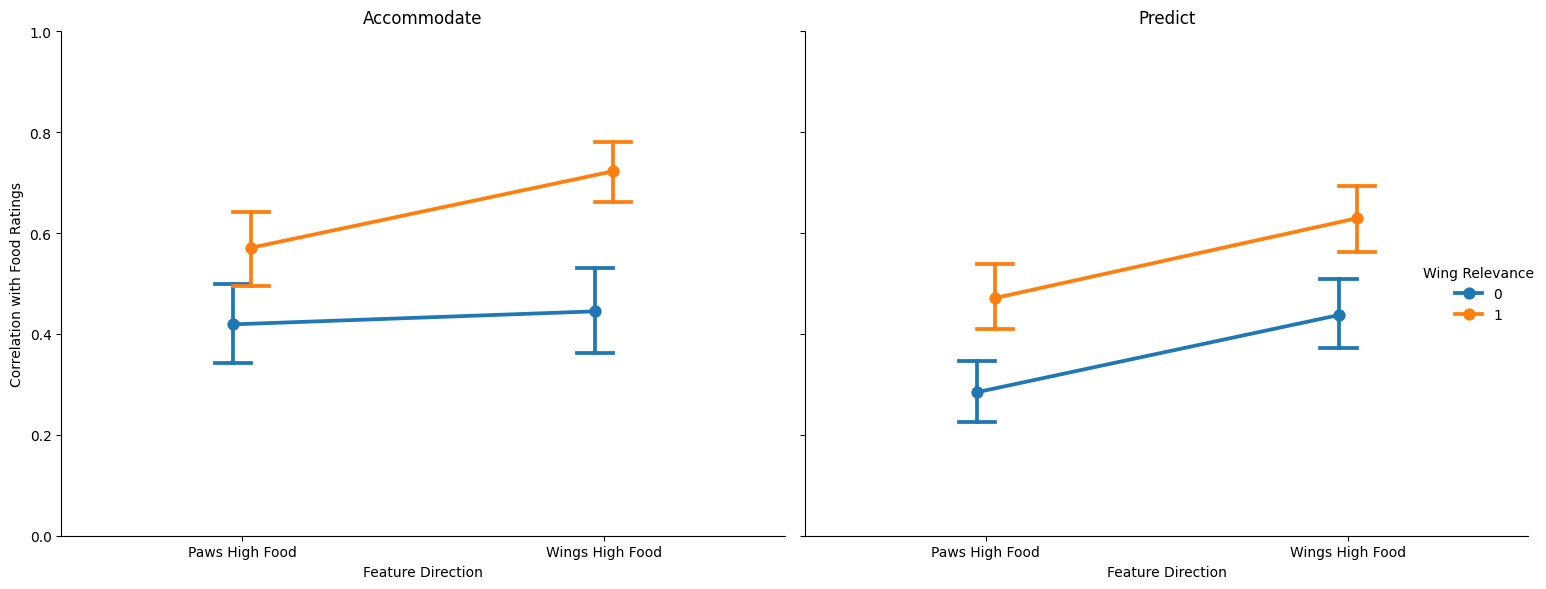

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

# Define x-axis labels
x_labels = ["Paws High Food", "Wings High Food"]

# Create catplot
g = sns.catplot(
    data=df_wing2,
    x="wing_present",
    y="abs_correlation",
    hue="wing_relevant",
    col="task",
    kind="point",
    dodge=True,
    capsize=0.1,
    markers="o",
    height=6,
    aspect=1.2
)

# Set axis limits
g.set(ylim=(0, 1))

# Set axis labels
g.set_axis_labels("Feature Direction", "Correlation with Food Ratings")

# Adjust x-tick labels and titles
for ax in g.axes.flatten():
    ax.set_xticks([0, 1])
    ax.set_xticklabels(x_labels)
    ax.set_title(ax.get_title().split(' = ')[-1].capitalize())  # clean task title

# Legend title
g._legend.set_title("Wing Relevance")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure9AbsWingCorrelationByTask.png'))
plt.show()


In [79]:
import statsmodels.formula.api as smf

# Convert categorical predictors
df_wing2["task"] = df_wing2["task"].astype('category')
df_wing2["wing_relevant"] = df_wing2["wing_relevant"].astype('category')
df_wing2["wing_present"] = df_wing2["wing_present"].astype('category')
df_wing2["participant"] = df_wing2["participant"].apply(lambda x: int(x[1]))
model_vars = ["correlation", "task", "wing_relevant", "wing_present", "participant"]
df_model = df_wing2[model_vars].dropna().copy()
df_model = df_model.reset_index(drop=True)
df_model = df_model.reset_index(drop=True)

# Fit model
model = smf.mixedlm(
    "correlation ~ task * wing_relevant * wing_present",
    data=df_model,
    groups=df_model["participant"]
)

result = model.fit(reml=False)
result.summary().tables[1].to_csv(os.path.join(outputdir, "Figure8mixedlm_correlationStats.csv"))
print(result.summary())


                             Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             correlation
No. Observations:               412                 Method:                         ML         
No. Groups:                     209                 Scale:                          0.1491     
Min. group size:                1                   Log-Likelihood:                 -201.9743  
Max. group size:                2                   Converged:                      Yes        
Mean group size:                2.0                                                            
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             0.122    0.056 

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [120]:
df_color2 = df_corr[df_corr["feature_dimension"] == "color"].copy()
df_color2["color_relevant"] = (df_color2["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_color2["color_present"] = (df_color2["high_value"] == "B").astype(int) #Code relevancy as 0/1
df_tail2 = df_corr[df_corr["feature_dimension"] == "tail"].copy()
df_tail2["tail_relevant"] = (df_tail2["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_tail2["tail_present"] = (df_tail2["high_value"] == "C").astype(int) #Code relevancy as 0/1

In [121]:
import statsmodels.formula.api as smf

# Convert categorical predictors
df_color2["task"] = df_color2["task"].astype('category')
df_color2["color_relevant"] = df_color2["color_relevant"].astype('category')
df_color2["color_present"] = df_color2["color_present"].astype('category')
df_color2["participant"] = df_color2["participant"].apply(lambda x: int(x[1]))
model_vars = ["correlation", "task", "color_relevant", "color_present", "participant"]
df_model = df_color2[model_vars].dropna().copy()
df_model = df_model.reset_index(drop=True)
df_model = df_model.reset_index(drop=True)

# Fit model
model = smf.mixedlm(
    "correlation ~ task * color_relevant * color_present",
    data=df_model,
    groups=df_model["participant"]
)

result = model.fit(reml=False)
result.summary().tables[1].to_csv(os.path.join(outputdir, "Figure8mixedlm_correlationStatsColor.csv"))
print(result.summary())


                              Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              correlation
No. Observations:               412                  Method:                          ML         
No. Groups:                     209                  Scale:                           0.1351     
Min. group size:                1                    Log-Likelihood:                  -182.1345  
Max. group size:                2                    Converged:                       Yes        
Mean group size:                2.0                                                              
-------------------------------------------------------------------------------------------------
                                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------
Intercept                                         

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [122]:
import statsmodels.formula.api as smf

# Convert categorical predictors
df_tail2["task"] = df_tail2["task"].astype('category')
df_tail2["tail_relevant"] = df_tail2["tail_relevant"].astype('category')
df_tail2["tail_present"] = df_tail2["tail_present"].astype('category')
df_tail2["participant"] = df_tail2["participant"].apply(lambda x: int(x[1]))
model_vars = ["correlation", "task", "tail_relevant", "tail_present", "participant"]
df_model = df_tail2[model_vars].dropna().copy()
df_model = df_model.reset_index(drop=True)
df_model = df_model.reset_index(drop=True)

# Fit model
model = smf.mixedlm(
    "correlation ~ task * tail_relevant * tail_present",
    data=df_model,
    groups=df_model["participant"]
)

result = model.fit(reml=False)
result.summary().tables[1].to_csv(os.path.join(outputdir, "Figure8mixedlm_correlationStatsTail.csv"))
print(result.summary())


                             Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             correlation
No. Observations:               412                 Method:                         ML         
No. Groups:                     209                 Scale:                          0.1347     
Min. group size:                1                   Log-Likelihood:                 -184.3252  
Max. group size:                2                   Converged:                      Yes        
Mean group size:                2.0                                                            
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             0.226    0.092 

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [80]:
import statsmodels.formula.api as smf

# Convert categorical predictors
df_wing2["task"] = df_wing2["task"].astype('category')
df_wing2["wing_relevant"] = df_wing2["wing_relevant"].astype('category')
df_wing2["wing_present"] = df_wing2["wing_present"].astype('category')
model_vars = ["abs_correlation", "task", "wing_relevant", "wing_present", "participant"]
df_model = df_wing2[model_vars].dropna().copy()
df_model = df_model.reset_index(drop=True)
df_model = df_model.reset_index(drop=True)

# Fit model
model = smf.mixedlm(
    "abs_correlation ~ task * wing_relevant * wing_present",
    data=df_model,
    groups=df_model["participant"]
)

result = model.fit(reml=False)
result.summary().tables[1].to_csv(os.path.join(outputdir, "Figure9mixedlm_AbscorrelationStats.csv"))
print(result.summary())


                             Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            abs_correlation
No. Observations:             412                Method:                        ML             
No. Groups:                   209                Scale:                         0.0584         
Min. group size:              1                  Log-Likelihood:                -21.6819       
Max. group size:              2                  Converged:                     Yes            
Mean group size:              2.0                                                              
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             0.419    0.036 

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [64]:
avg_corr_task_rel = df_wing2.groupby(
    ['task', 'wing_present'],
    as_index=False
)['correlation'].mean()
print(avg_corr_task_rel)

          task wing_present  correlation
0  accommodate            0     0.253719
1  accommodate            1     0.526822
2      predict            0     0.167956
3      predict            1     0.492109


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_1628/1830877773.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_corr_task_rel = df_wing2.groupby(


In [65]:
avg_corr_task_rel = df_wing2.groupby(
    ['task', 'wing_relevant', 'wing_present'],
    as_index=False
)['correlation'].mean()
print(avg_corr_task_rel)

          task wing_relevant wing_present  correlation
0  accommodate             0            0     0.121405
1  accommodate             0            1     0.344812
2  accommodate             1            0     0.383440
3  accommodate             1            1     0.708833
4      predict             0            0     0.057273
5      predict             0            1     0.367453
6      predict             1            0     0.278638
7      predict             1            1     0.619209


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_1628/945449836.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_corr_task_rel = df_wing2.groupby(


In [91]:
avg_corr_task_rel = df_wing2.groupby(
    ['task', 'wing_relevant', 'wing_present'],
    as_index=False
)['abs_correlation'].mean()
print(avg_corr_task_rel)

          task wing_relevant wing_present  abs_correlation
0  accommodate             0            0         0.419047
1  accommodate             0            1         0.444848
2  accommodate             1            0         0.570999
3  accommodate             1            1         0.722526
4      predict             0            0         0.284409
5      predict             0            1         0.437400
6      predict             1            0         0.471093
7      predict             1            1         0.629334


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_1628/3004305803.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_corr_task_rel = df_wing2.groupby(


In [66]:
avg_corr_task_rel = df_corr.groupby(
    ['task'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)
avg_corr_feature = df_corr.groupby(
    ['feature_dimension'],
    as_index=False
)['correlation'].mean()

print(avg_corr_feature)
avg_corr_relevance = df_corr.groupby(
    ['feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_relevance)

          task  correlation
0  accommodate     0.294649
1      predict     0.261714
  feature_dimension  correlation
0             color     0.292936
1              tail     0.180762
2              wing     0.360606
  feature_relevance  correlation
0        irrelevant     0.156864
1          relevant     0.338720


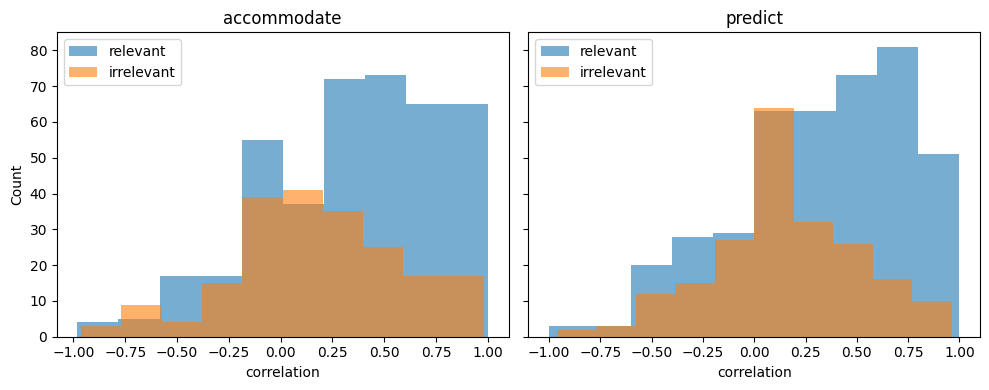

In [70]:
tasks = df_corr['task'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tasks),
    figsize=(5 * len(tasks), 4),
    sharey=True
)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    for label in ['relevant', 'irrelevant']:
        values = df_corr.loc[
            (df_corr['task'] == task) &
            (df_corr['feature_relevance'] == label),
            'correlation'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=label)

    ax.set_title(task)
    ax.set_xlabel("correlation")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure9_FeatureCorrelationeByTaskAndRelevance.png'), dpi=300)
plt.show()


In [87]:
print(df_corr)

         participant         task feature_dimension high_value  \
0   (accommodate, 1)  accommodate             color          G   
1   (accommodate, 1)  accommodate              feet          C   
2   (accommodate, 2)  accommodate             color          G   
3   (accommodate, 2)  accommodate              feet          F   
4   (accommodate, 3)  accommodate             color          Y   
..               ...          ...               ...        ...   
75     (predict, 18)      predict              feet          F   
76     (predict, 19)      predict             color          Y   
77     (predict, 19)      predict              feet          F   
78     (predict, 20)      predict             color          Y   
79     (predict, 20)      predict              feet          F   

   feature_relevance  correlation irrelevant_dim  abs_correlation  
0           relevant     0.548821          color         0.548821  
1           relevant     0.768350          color         0.768350  
2  

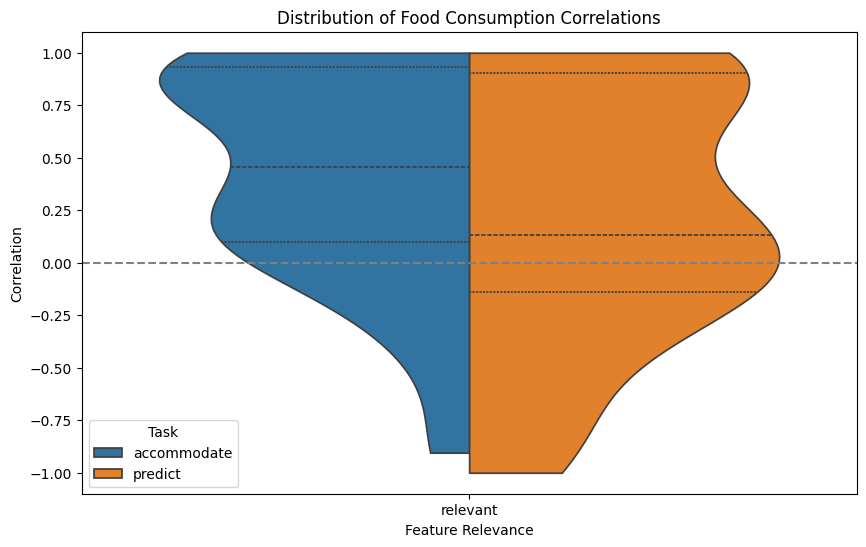

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_corr,
    x='feature_relevance',      # relevant / irrelevant
    y='correlation',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Food Consumption Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


In [69]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  correlation
0  accommodate        irrelevant     0.177281
1  accommodate          relevant     0.353333
2      predict        irrelevant     0.136645
3      predict          relevant     0.324248


In [71]:
nan_corrs = df_corr[pd.isna(df_corr['correlation'])]
#print(nan_corrs)
df_corr_clean = df_corr[pd.notna(df_corr['correlation'])].copy()



In [72]:
import statsmodels.formula.api as smf

md = smf.mixedlm(
    "correlation ~ task * feature_relevance",
    df_corr_clean,
    groups=df_corr_clean["participant"],  # random intercept per participant
    re_formula="~feature_relevance"  # random slopes if it converges
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_correlation.csv"))


                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           correlation
No. Observations:            1236              Method:                       REML       
No. Groups:                  412               Scale:                        0.1644     
Min. group size:             3                 Log-Likelihood:               -657.4549  
Max. group size:             3                 Converged:                    Yes        
Mean group size:             3.0                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      0.177    0.028  6.238 0.000  0.122  0.233
task[T.predict]                               -

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Supplementary: Irrelevant Feature Association with food amount and food consumption ratings

Supplementary Models Looking at Feature Dimension

In [ ]:
import ast
import matplotlib.pyplot as plt
#Calculate reported food amounts during testing
def AverageFoodCalclator(participants_to_use):
    df_subset = df_combined[df_combined['participant'].isin(participants_to_use)]
    all_trials = []
    for i in df_subset['participant']:
        ratings     = df_subset[df_subset['participant'] == i]['testing_responses'].iloc[0]
        categories = df_subset[df_subset['participant'] == i]['testing_categories'].iloc[0]
        task = df_subset[df_subset['participant'] == i]['task'].iloc[0]
        row = df_subset[df_subset['participant'] == i].iloc[0]
        tail_yes  = 1 if row['tail_discrete_slider.response']  == 'Yes' else 0
        shape_yes = 1 if row['shape_discrete_slider.response'] == 'Yes' else 0
        color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0
        num_features_relevant = tail_yes + shape_yes + color_yes
        df_participant = pd.DataFrame(list(zip(
            [i]*len(ratings),  # Repeat participant ID and task to match the number of ratings
            ratings,
            [task]*len(ratings), # Repeat participant ID and task to match the number of ratings
            categories,
            [num_features_relevant]*len(ratings)
        )), columns=['participant', 'ratings', 'task', 'category', 'num_features_relevant'])
        all_trials.append(df_participant)
    df_average = pd.concat(all_trials, ignore_index=True)
    avg_ratings_cond = df_average.groupby(['task', 'category'])['ratings'].mean()
    return df_average, avg_ratings_cond

participants_to_use = df_combined['participant'].tolist()
df_average, avg_rating_cond = AverageFoodCalclator(participants_to_use)
print(avg_rating_cond)
print(df_average)
# Group by task, category, and num_features_relevant
model_parameter_score = df_average.groupby(
    ['num_features_relevant']
)['ratings'].mean().reset_index()

print(model_parameter_score)
# Group by task, category, and num_features_relevant
avg_ratings_cond_by_relevance = df_average.groupby(
    ['task', 'category', 'num_features_relevant']
)['ratings'].mean().reset_index()


print(avg_ratings_cond_by_relevance)
category_order = ['low', 'medium', 'high']
avg_ratings_cond_by_relevance['category'] = pd.Categorical(
    avg_ratings_cond_by_relevance['category'],
    categories=category_order,
    ordered=True
)
import seaborn as sns
sns.catplot(
    data=avg_ratings_cond_by_relevance,
    x='category', y='ratings',
    hue='num_features_relevant', col='task',
    kind='bar', palette='Set2'
)
plt.show()

<Axes: xlabel='category', ylabel='ratings'>

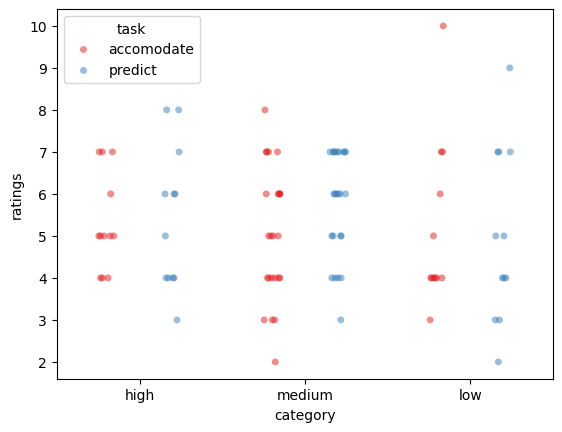

In [ ]:
sns.stripplot(data=df_average, x='category', y='ratings', hue='task', 
              palette='Set1', dodge=True, jitter=True, color='black', alpha=0.5)

In [ ]:
print(df_average.head(20))

    participant  ratings        task category  num_features_relevant
0             1      6.0  accomodate     high                      1
1             1      5.0  accomodate   medium                      1
2             1      3.0  accomodate      low                      1
3             1      5.0  accomodate   medium                      1
4             1      5.0  accomodate   medium                      1
5             1      7.0  accomodate     high                      1
6             1      4.0  accomodate      low                      1
7             1      4.0  accomodate   medium                      1
8             2      5.0  accomodate   medium                      2
9             2      3.0  accomodate   medium                      2
10            2      5.0  accomodate     high                      2
11            2      7.0  accomodate      low                      2
12            2      7.0  accomodate     high                      2
13            2      5.0  accomoda

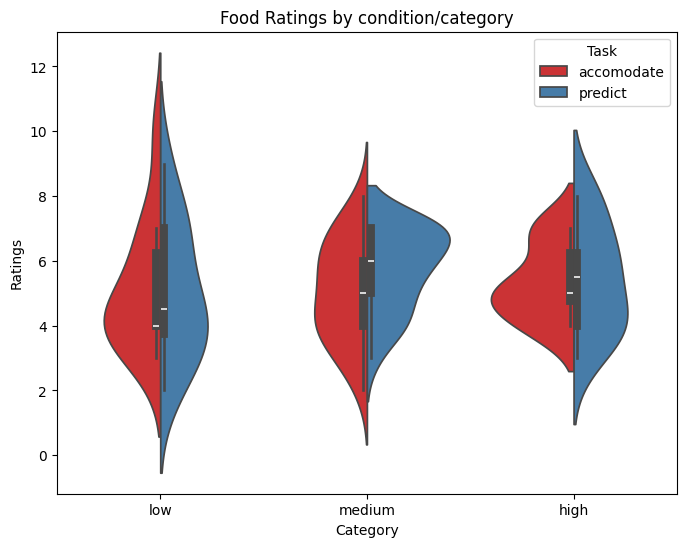

In [ ]:
order = ['low', 'medium', 'high']
# Violin plot: ratings by category, separated by task
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_average,
    x='category',       # x-axis: categories
    y='ratings',        # y-axis: ratings
    hue='task',         # split by task
    split=True,         # split the violins by task
    palette='Set1',
    inner='box',    # show box plot of data inside
    order = order
)

plt.ylabel('Ratings')
plt.xlabel('Category')
plt.title('Food Ratings by condition/category')
plt.legend(title='Task')
#plt.savefig(f'{study}Plots/ViolinRatings.png', bbox_inches='tight')
plt.show()

In [ ]:
def decode_rel(rel_values):
    """
    rel_values: Series of lists of rel codes
    """

    flat_vals = []
    for v in rel_values:
        if isinstance(v, list):
            flat_vals.extend(v)

    flat_vals = pd.Series(flat_vals).dropna().unique()

    if len(flat_vals) == 0:
        return pd.Series({'feature_relevance': np.nan})

    # irrelevant: only I-codes
    if all(v.startswith('I') for v in flat_vals):
        return pd.Series({'feature_relevance': 'irrelevant'})

    # relevant: contains R or L
    if any(v.startswith(('R', 'L')) for v in flat_vals):
        return pd.Series({'feature_relevance': 'relevant'})

    raise ValueError(f"Unexpected rel codes: {flat_vals}")


feature_relevance_rows = []

for (cond, task), subdf in df_combined.groupby(['conditionOrder', 'task']):
    for feat in ['tail', 'color', 'shape']:
        relevance = decode_rel(subdf[f'training_{feat}'])

        feature_relevance_rows.append({
            'conditionOrder': cond,
            'task': task,
            'feature_dimension': feat,
            'feature_relevance': relevance
        })

df_feature_relevance = pd.DataFrame(feature_relevance_rows)
print(df_feature_relevance)

    conditionOrder        task feature_dimension  \
0                1  accomodate              tail   
1                1  accomodate             color   
2                1  accomodate             shape   
3                1     predict              tail   
4                1     predict             color   
5                1     predict             shape   
6                2  accomodate              tail   
7                2  accomodate             color   
8                2  accomodate             shape   
9                2     predict              tail   
10               2     predict             color   
11               2     predict             shape   
12               3  accomodate              tail   
13               3  accomodate             color   
14               3  accomodate             shape   
15               3     predict              tail   
16               3     predict             color   
17               3     predict             shape   
18          

In [ ]:
features = ['shape', 'color', 'tail']
long_rows = []

for _, row in df_combined.iterrows():
    for feat in features:
        long_rows.append({
            'participant': row['participant'],
            'conditionOrder': row['conditionOrder'],
            'task': row['task'],
            'feature_dimension': feat,

            'discrete': row[f'{feat}_discrete_slider.response'],
            'direction': row[f'{feat}_direction_slider.response'],
            'continuous': row[f'{feat}_continuous_slider.response'],
        })

df_long = pd.DataFrame(long_rows)
print(df_long.head(10))

   participant  conditionOrder        task feature_dimension discrete  \
0            1               4  accomodate             shape      Yes   
1            1               4  accomodate             color       No   
2            1               4  accomodate              tail       No   
3            2               1  accomodate             shape       No   
4            2               1  accomodate             color      Yes   
5            2               1  accomodate              tail      Yes   
6            3               3  accomodate             shape      Yes   
7            3               3  accomodate             color      Yes   
8            3               3  accomodate              tail      Yes   
9            4               2  accomodate             shape      Yes   

       direction  continuous  
0         Square         5.0  
1            NaN         NaN  
2            NaN         NaN  
3            NaN         NaN  
4           Blue         4.0  
5  Having 

In [ ]:
df_long = df_long.merge(
    df_feature_relevance,
    on=['conditionOrder', 'task', 'feature_dimension'],
    how='left'
)
print(df_long.head(21))

    participant  conditionOrder        task feature_dimension discrete  \
0             1               4  accomodate             shape      Yes   
1             1               4  accomodate             color       No   
2             1               4  accomodate              tail       No   
3             2               1  accomodate             shape       No   
4             2               1  accomodate             color      Yes   
5             2               1  accomodate              tail      Yes   
6             3               3  accomodate             shape      Yes   
7             3               3  accomodate             color      Yes   
8             3               3  accomodate              tail      Yes   
9             4               2  accomodate             shape      Yes   
10            4               2  accomodate             color      Yes   
11            4               2  accomodate              tail      Yes   
12            5               2     pr